In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d

import tqdm as tqdm

from scipy.ndimage import gaussian_filter1d

from matplotlib.lines import Line2D



In [2]:
### Plot helpers

plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX to render all text
    "text.latex.preamble": r"\usepackage{amsmath}", # Load amsmath for advanced math typography
    "font.family": "serif",                   # Use a serif font for the main text
    "font.serif": ["Computer Modern Roman"],  # Match standard LaTeX default font
    "font.size": 14,                          # Standard font size for scientific papers
    "axes.labelsize": 14,                     # Size of the x and y axis labels
    "xtick.labelsize": 12,                     # Size of the x-tick labels
    "ytick.labelsize": 12,                     # Size of the y-tick labels
    "legend.fontsize": 12,                     # Size of the legend text
    "figure.titlesize": 16                    # Size of the figure's main title
})

# colorblind-friendly palette
colors_colorblind = ['#377eb8', '#ff7f00', '#4daf4a',
          '#f781bf', '#a65628', '#984ea3',
          '#999999', '#e41a1c', '#dede00']

In [3]:
# =======================
# BASE COSMOLOGY: Planck 2015 TT,TE,EE+lowE
# =======================
h_fixed     = 0.6727
theta_s_100 = 1.041783
omega_b     = 0.022383
omega_cdm0  = 0.12011
tau_reio    = 0.0543
A_s         = 2.1005829616811546e-9
n_s         = 0.96605

base_params = {
    '100*theta_s': 1.041783,
    #"h": h_fixed,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,
}

In [4]:
### RUN LCDM for comparison first
lcdm = Class()
lcdm.set(base_params)
lcdm.set({
    "output": "mPk",
    "P_k_max_h/Mpc": 10.0,
    "z_pk": 0.0,
})
lcdm.compute()

### Read background quantities for LCDM

bg_lcdm = lcdm.get_background()
z_lcdm = bg_lcdm['z']
a_lcdm = 1/(1+z_lcdm)
rho_cdm_lcdm = bg_lcdm['(.)rho_cdm']
rho_g_lcdm = bg_lcdm['(.)rho_g']
# rho_nu_lcdm = bg_lcdm['(.)rho_ncdm[0]']
H_lcdm = bg_lcdm['H [1/Mpc]']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']
z_eq_lcdm = lcdm.get_current_derived_parameters(['z_eq'])
print(f"Redshift of matter-radiation equality in LCDM: {z_eq_lcdm['z_eq']:.2f}")

kk = np.logspace(-4,0,1000) # k in h/Mpc
h = lcdm.h() # get reduced Hubble for conversions to 1/Mpc
Pk_lcdm = [] # P(k) in (Mpc/h)**3
for k in kk:
    Pk_lcdm.append(lcdm.pk(k*h,0.)*h**3) # function .pk(k,z)


Redshift of matter-radiation equality in LCDM: 3405.82


In [5]:
### Constants

num_of_gigayears = 0.1
tau_acc = num_of_gigayears*3600*24*365*1e9 # convert to seconds
f_acc = 0.1 # rho_acc/rho_cdm today
m_dcdm = 1e15
m_wdm = 1e-10 # smaller, to make it relativistic
omega_dm = 0.1201075
# kappa = 12
a_t = 0.01
eta = np.sqrt(2)-1 #sqrt(2)-1 gives P = m_dcdm, so DCDM->DR with "one relativistic decay product" -- if I wanted to have more realistic DCDM->2DR P=m_dcdm/2 I'd have to double number density

kappa_list = [0.01, 0.1, 0.5, 1.0] #[0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
a_rec = 1/(1+1100) # scale factor at recombination, approximation to adjust omega_cdm 
k_values = [1e-3, 1e-2, 1e-1, 1]
k_values_CLASS = ', '.join([str(k) for k in k_values])


In [6]:
### Run CLASS for AccDM model ###

# Output dictionaries
AccCLASS = {}
bgAcc, pbAcc, clAcc = {}, {}, {}
Pk = {}

ncdm_q_steps = 301 ### Make sure that this is odd

for kappa in tqdm.tqdm(kappa_list):
    if (m_wdm*(1+eta) > 1e19) or (m_dcdm > 1e19):
        print(f"Warning: energy of the WDM particle after acceleration is {m_wdm*(1+eta):.2e} GeV, which is above the Planck scale.")
        break
    omega_c_new = omega_cdm0*(1+f_acc*(1-a_rec**kappa)/(1+(a_rec/a_t)**kappa))**(-1)
    print(f"Running CLASS for kappa={kappa} with adjusted omega_cdm={omega_c_new:.5f} to keep theta_s fixed...")
    
    AccCLASS = Class()
    AccCLASS.set(base_params)
    AccCLASS.set({  'output': 'tCl, pCl, lCl, mPk',
                    'l_max_scalars': 2500,
                    'k_output_values': k_values_CLASS,
                    'omega_cdm': omega_cdm0*(1+f_acc*(1-a_rec**kappa)/(1+(a_rec/a_t)**kappa))**(-1),
                    # accDM params
                    'vary_Gamma_wdm': 'yes',                    # Use the more general formulation
                    'kappa_mon':      kappa,                    # Acceleration speed parameter
                    'a_t_mon':        a_t,                      # Roughly speaking the scale factor at which the acceleration happens
                    'f_wdm':          f_acc,                    # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
                    'eta_wdm':        eta,                      # Energy gain of the WDM component defined via the enrgy right after acceleration E_wdm = m_wdm(1+\eta)
                    "tau_wdm":        tau_acc,                  # REMOVE, Irrelevant in this formulation, but set it to a large value to avoid issues with the code, since we are not using the decay formulation
                    "m_wdm_in_GeV":   m_wdm,                    # accDM mass in GeV
                    "m_cdm_in_GeV":   m_dcdm,                   # DCDM mass in GeV, in accDM case these two masses should be the same, but this implementation is more general
                    # ncdm params [0] is for the neutrinos, [1] is for the WDM component
                    "N_ncdm":                   1,              # accDM is always the last ncdm species, so it has index N_ncdm-1, here we sset N_ncdm=2 to have both massive neutrinos and accDM in the ncdm sector
                    "deg_ncdm":                 1 ,             # 3 neutrino species and 1 degrees of freedom for the WDM component 
                    "m_ncdm":                   m_wdm*1e9,      # Set a small mass for the neutrino species and a large mass for the WDM component (in eV), the 2nd entry shuld be irrelevant as m_ncdm[1] should be overwritten in the code by m_wdm_in_GeV
                    "T_ncdm":                   1,              # Set the same temperature for the WDM component as for the neutrinos,
                    "N_ur":                     3.044,          # Set the number of massless neutrino species to 0 since we are including them as ncdm species
                    "ncdm_quadrature_strategy": 4,              # Quadrature strategy for each ncdm species, 0 (CLASS auto quadrature) for neutrinos, 4 for WDM (logarithmic Simpson, added in CLASS by me based on 2102.12498 -- the repo linked in this paper has WRONG IMPLEMENTATION!)
                    "ncdm_N_momentum_bins" :    ncdm_q_steps,   # Set a higher number of momentum bins for the WDM component, maybe the same number as evolution steps? But that's 40000, so a lot. FOR SIMPSION THE NUBMER OF MOMENTUM BINS SHOULD BE ODD, CHECK THIS
                    # precision
                    'reionization_z_start_max': 80,      # Default is 50, 80 is the minimal value that works for the chosen eta values if we set tau_reio to Planck 2018 value, it just widens the bracket so that this doesn't cause issue with shooting for h
                    "ncdm_fluid_approximation": 3,
                    "switch_on_eq_delta_p_wdm": 'no', 
                    "switch_off_shear_wdm": 'yes', 
                    #"ncdm_fluid_trigger_tau_over_tau_k": 25,
                    'evolver': 0
                    })
    AccCLASS.compute()
    bgAcc[kappa] = AccCLASS.get_background()
    pbAcc[kappa] = AccCLASS.get_perturbations()
    clAcc[kappa] = AccCLASS.raw_cl(2500)
    
    ### MATTER POWER SPECTRUM
    Pk['AccDM', kappa] = [] # P(k) in (Mpc/h)**3
    h = AccCLASS.h() # get reduced Hubble for conversions to 1/Mpc
    for k in kk:
        Pk['AccDM', kappa].append(AccCLASS.pk(k*h,0.)*h**3) # function .pk(k,z)
    

  0%|          | 0/4 [00:00<?, ?it/s]

Running CLASS for kappa=0.01 with adjusted omega_cdm=0.11970 to keep theta_s fixed...


 25%|██▌       | 1/4 [00:24<01:14, 24.75s/it]

Running CLASS for kappa=0.1 with adjusted omega_cdm=0.11682 to keep theta_s fixed...


 50%|█████     | 2/4 [00:49<00:49, 24.99s/it]

Running CLASS for kappa=0.5 with adjusted omega_cdm=0.11178 to keep theta_s fixed...


 75%|███████▌  | 3/4 [01:12<00:23, 23.93s/it]

Running CLASS for kappa=1.0 with adjusted omega_cdm=0.11003 to keep theta_s fixed...


100%|██████████| 4/4 [01:38<00:00, 24.72s/it]


In [7]:
### Run CLASS for DCDM->DR model for comparison

#DCDM_CLASS = {}
bgDCDM, pbDCDM, clDCDM = {}, {}, {}
Pk_dcdm = {}

for kappa in tqdm.tqdm(kappa_list):
    DCDM_CLASS = Class()
    DCDM_CLASS.set(base_params)
    DCDM_CLASS.set({    'output': 'tCl, pCl, lCl, mPk',
                        'l_max_scalars': 2500,
                        'k_output_values': k_values_CLASS,
                        'omega_cdm': omega_cdm0*(1+f_acc*(1-a_rec**kappa)/(1+(a_rec/a_t)**kappa))**(-1), # Adjust omega to keep theta_s fixed
                        # accDM params
                        #'vary_Gamma_wdm': 'no',                     # Don't use the more general formulation, but the decay formulation for a direct comparison with the DCDM->DR case
                        'kappa_mon':      kappa,               # Acceleration parameter
                        'a_t_mon':        a_t,                 # Roughly speaking the scale factor at which the acceleration happens
                        'f_mon':          f_acc,               # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
                        })
    DCDM_CLASS.compute()
    bgDCDM[kappa] = DCDM_CLASS.get_background()
    pbDCDM[kappa] = DCDM_CLASS.get_perturbations()
    clDCDM[kappa] = DCDM_CLASS.raw_cl(2500)
    
    ## MATTER POWER SPECTRUM
    Pk_dcdm['DCDM->DR', kappa] = [] # P(k) in (Mpc/h)**3
    h = DCDM_CLASS.h() # get reduced Hubble for conversions to 1/Mpc
    for k in kk:
        Pk_dcdm['DCDM->DR', kappa].append(DCDM_CLASS.pk(k*h,0.)*h**3) # function .pk(k,z)

100%|██████████| 4/4 [00:05<00:00,  1.27s/it]


In [9]:
# Background
z, a, H = {}, {}, {}
rho_g, rho_cdm, rho_dcdm, rho_b, rho_ur, rho_lambda = {}, {}, {}, {}, {}, {}
rho_acc, rho_dr, p_acc = {}, {}, {}
smooth_rho_acc, smooth_p_acc = {}, {}
rho_nu, p_nu = {}, {}
rho_tot, rho_crit = {}, {}

# Perturbations
delta_cdm, delta_g, delta_b, delta_nu, delta_ur = {}, {}, {}, {}, {}
delta_dcdm, delta_acc, delta_dr = {}, {}, {}

# CMB spectra
ll, clTT, clEE, clTE, clPP = {}, {}, {}, {}, {}

# Other
z_eq = {}

models = ['AccDM', 'DCDM->DR']

for kappa in kappa_list:    
    for model in models:
        if model == 'AccDM':
            bg = bgAcc[kappa]
            pb = pbAcc[kappa]
            cl = clAcc[kappa]
        elif model == 'DCDM->DR':
            bg = bgDCDM[kappa]
            pb = pbDCDM[kappa]
            cl = clDCDM[kappa]
        else:
            raise ValueError(f"Unknown model: {model}")
        
        H[model, kappa] = bg['H [1/Mpc]']
        z[model, kappa] = bg['z']
        a[model, kappa] = 1/(1+z[model, kappa])
        
        # The usual components of the universe
        rho_g[model, kappa] = bg['(.)rho_g'] 
        rho_b[model, kappa] = bg['(.)rho_b']
        rho_cdm[model, kappa] = bg['(.)rho_cdm']
        rho_lambda[model, kappa] = bg['(.)rho_lambda']
        rho_ur[model, kappa] = bg['(.)rho_ur']
        # rho_nu[model, kappa] = bg['(.)rho_ncdm[0]']
        # p_nu[model, kappa] = bg['(.)p_ncdm[0]']

        # Energy densities of the DCDM and WDM components and the pressure of the WDM component
        if model == 'AccDM':
            rho_dcdm[model, kappa] = bg['(.)rho_dcdm']
            rho_acc[model, kappa] = bg['(.)rho_ncdm[0]']
            p_acc[model, kappa] = bg['(.)p_ncdm[0]']
            rho_dr[model, kappa] = 0
        else:
            rho_dcdm[model, kappa] = bg['(.)rho_mon']
            rho_acc[model, kappa] = 0 # there is no acc component in DCDM->DR model
            p_acc[model, kappa] = 0
            rho_dr[model, kappa] = bg['(.)rho_dr']

        # Total and critical energy densities
        rho_tot[model, kappa] = bg['(.)rho_tot']
        rho_crit[model, kappa] = bg['(.)rho_crit']
        
        for i in range(len(k_values)):
            scalar_data = pb['scalar'][i]  # Scalar perturbations for selected k-values
            # print(scalar_data.keys())
            a[model, kappa, k_values[i]] = scalar_data['a']
            
            # Extract perturbation quantities
            delta_cdm[model, kappa, k_values[i]] = scalar_data['delta_cdm']
            delta_g[model, kappa, k_values[i]] = scalar_data['delta_g']
            delta_b[model, kappa, k_values[i]] = scalar_data['delta_b']
            delta_ur[model, kappa, k_values[i]] = scalar_data['delta_ur']
            # delta_nu[model, kappa, k_values[i]] = scalar_data['delta_ncdm[0]']
            
            if model == 'AccDM':
                delta_dcdm[model, kappa, k_values[i]] = scalar_data['delta_dcdm']
                delta_acc[model, kappa, k_values[i]] = scalar_data['delta_ncdm[0]']
                delta_dr[model, kappa, k_values[i]] = 0
            else:
                delta_acc[model, kappa, k_values[i]] = 0 # there is no acc component in DCDM->DR model
                delta_dr[model, kappa, k_values[i]] = scalar_data['delta_dr']
                delta_dcdm[model, kappa, k_values[i]] = scalar_data['delta_mon']
            
        ### POWER SPECTRUM
        
        ll[model, kappa] = cl['ell'][2:]
        clTT[model, kappa] = cl['tt'][2:]
        clEE[model, kappa] = cl['ee'][2:]
        clTE[model, kappa] = cl['te'][2:]
        clPP[model, kappa] = cl['pp'][2:]
    

1e+198
1e+18
100.0
1.0


/tmp/ipykernel_201756/2424907280.py:18: RuntimeWarning: invalid value encountered in divide
  ax.plot(a_acc, rho_dcdm['AccDM', kappa]/rho_dcdm['DCDM->DR', kappa]-1, label=r'$\kappa = {}$'.format(kappa), ls = '-', color=colors_colorblind[kappa_list.index(kappa)])


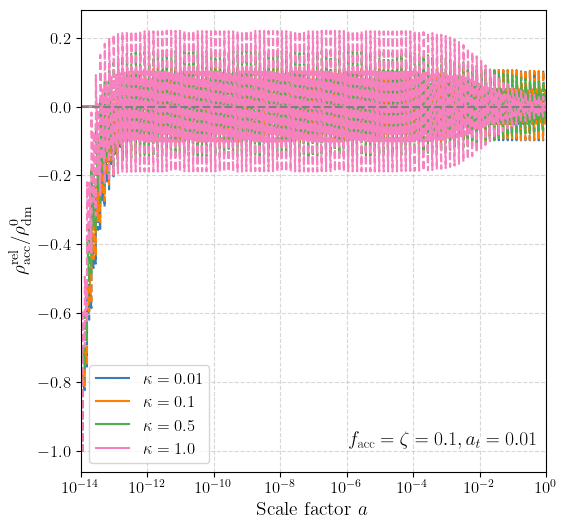

In [10]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

rho_cdm_lcdm_interp = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

for kappa in kappa_list:
    # print(f'Plotting for kappa = {kappa}')
    a_acc = a['AccDM', kappa]
    a_mon = a['DCDM->DR', kappa]
    
    rho_acc_rel = 3*p_acc['AccDM', kappa]
    rho_acc_nonrel = rho_acc['AccDM', kappa] - rho_acc_rel
    
    rho_dr_mon = rho_dr['DCDM->DR', kappa]
    # print(rho_dr_mon)
    print(np.pow(100, 1/kappa)*a_t)
    
    ax.plot(a_acc, rho_dcdm['AccDM', kappa]/rho_dcdm['DCDM->DR', kappa]-1, label=r'$\kappa = {}$'.format(kappa), ls = '-', color=colors_colorblind[kappa_list.index(kappa)])
    
    ax.plot(a_acc, rho_acc['AccDM', kappa]/rho_dr['DCDM->DR', kappa]-1, ls = '--', color=colors_colorblind[kappa_list.index(kappa)])
    
    # ax.plot(a_mon, rho_dr_mon, ls = '--', color=colors_colorblind[kappa_list.index(kappa)])
    
    ax.set_ylabel(r'$\rho_\mathrm{acc}^\mathrm{rel}/\rho_\mathrm{dm}^0$')
    ax.set_xlabel(r'Scale factor $a$')

ax.axhline(0, color='grey', linestyle='--')

ax.text(1.0, 0.05, rf'$f_\mathrm{{acc}} = \zeta = {f_acc}, a_t = {a_t}$', transform=ax.transAxes, fontsize=14, color='black', ha='right', va='bottom', path_effects=[pe.withStroke(linewidth=3, foreground='white')])

ax.legend()
# ax.set_title('Relativistic part of accDM for different values of $\kappa$')
ax.set_yscale('linear')
ax.set_xscale('log')
# ax.set_ylim(1e-9, 1e-1)
ax.set_xlim(1e-14, 1)
ax.grid(ls = '--', alpha = 0.5)
# ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{acc}}$')


w_acc today for kappa = 0.01: 0.3333
w_acc today for kappa = 0.1: 0.3333
w_acc today for kappa = 0.5: 0.3333
w_acc today for kappa = 1.0: 0.3333


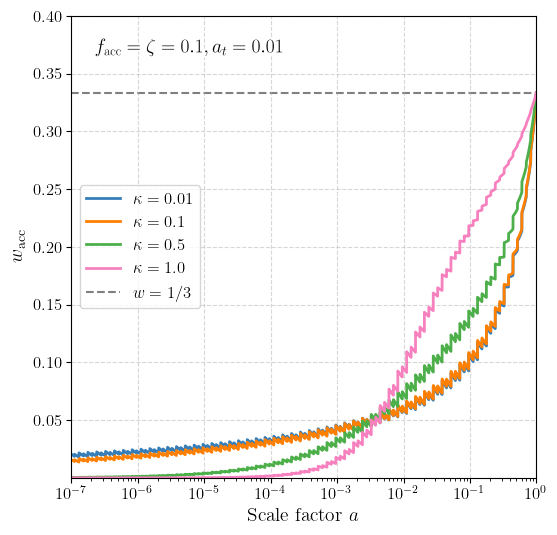

In [11]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

colors = colors_colorblind

for kappa in kappa_list:
    a_acc = a['AccDM', kappa]
    
    w_acc = p_acc['AccDM', kappa]/(rho_acc['AccDM', kappa]+rho_dcdm['AccDM', kappa])
    print(f"w_acc today for kappa = {kappa}: {w_acc[-1]:.4f}")
    
    ax.semilogx(a_acc, w_acc, label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '-', color = colors_colorblind[kappa_list.index(kappa)])

    ax.set_ylabel(r'$w_\mathrm{acc}$')
    ax.set_xlabel(r'Scale factor $a$')
    
# w_nu = p_nu[kappa]/rho_nu[kappa]
# ax.semilogx(a_acc, w_nu, label=r'$\nu$', linewidth=2, ls = '--', color='grey')

# ax.axhline(1, color='grey', linestyle='--')
ax.axhline(1/3, color='grey', linestyle='--', label=r'$w=1/3$', zorder=-1)
ax.text(0.05, 0.95, rf'$f_\mathrm{{acc}} = \zeta = {f_acc}, a_t = {a_t}$', transform=ax.transAxes, fontsize=14, color='black', ha='left', va='top', path_effects=[pe.withStroke(linewidth=3, foreground='white')])
ax.legend()
ax.set_yscale('linear')
ax.set_ylim(1e-4, 0.4)
ax.set_xlim(1e-7, 1)
ax.grid(ls = '--', alpha = 0.5)


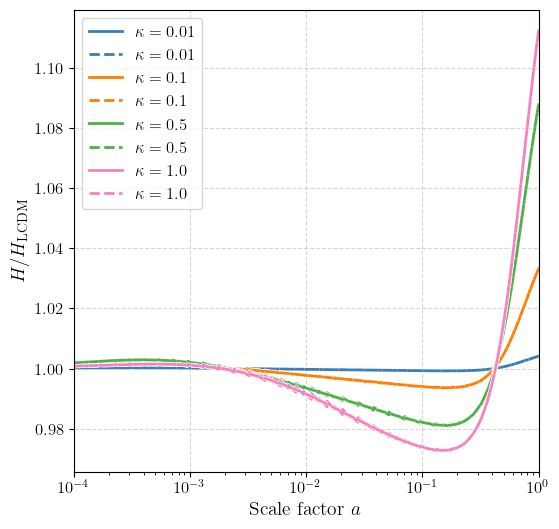

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
colors = colors_colorblind

### interpolate H_lcdm to the same a values as in the accDM cases for easier comparison
H_lcdm_interp = interp1d(a_lcdm, H_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')


for kappa in kappa_list:
    a_acc = a['AccDM', kappa]
    a_mon = a['DCDM->DR', kappa]
    H_lcdm_at_acc = H_lcdm_interp(a_acc)
    H_lcdm_at_mon = H_lcdm_interp(a_mon)
    
    # ax.plot(a_acc, H['AccDM', kappa]/H_lcdm_at_acc, label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '-', color = colors_colorblind[kappa_list.index(kappa)])
    # ax.plot(a_mon, H['DCDM->DR', kappa]/H_lcdm_at_mon, label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '--', color = colors_colorblind[kappa_list.index(kappa)])
    
    ax.plot(a_acc, H['AccDM', kappa]/H_lcdm_at_acc, label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '-', color = colors_colorblind[kappa_list.index(kappa)], path_effects=[pe.withStroke(linewidth=3, foreground='white')])
    ax.plot(a_mon, H['DCDM->DR', kappa]/H_lcdm_at_mon, label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '--', color = colors_colorblind[kappa_list.index(kappa)], path_effects=[pe.withStroke(linewidth=3, foreground='white')])
    
    ax.set_ylabel(r'$H/H_{\rm LCDM}$')
    ax.set_xlabel(r'Scale factor $a$')
   
# ax.plot(a_lcdm, H_lcdm, label=r'$\Lambda$CDM', linewidth=2, ls = '--', color = 'grey')

      
ax.legend()
ax.set_yscale('linear')
ax.set_xscale('log')
# ax.set_ylim(1e-4, 1e9)
ax.set_xlim(1e-4, 1)
ax.grid(ls = '--', alpha = 0.5)

In [ ]:
# # Set up figure
# fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# # Interpolation functions
# interp_H_lcdm = interp1d(a_lcdm, H_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')
# interp_rho_cdm_lcdm = interp1d(a_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

# colors = colors_colorblind

# # Loop over f_mon values
# for i, kappa in enumerate(kappa_list):
#     z_mon = z[kappa]
#     a_mon = a[kappa]
#     H_mon = H[kappa]
#     rho_cdm_mon = rho_cdm[kappa]
#     rho_acc_mon = smooth_rho_acc[kappa]
#     rho_dcdm_mon = rho_dcdm[kappa]
    
#     rho_tot = rho_g[kappa] + rho_b[kappa] + rho_cdm[kappa] + rho_dcdm[kappa] + rho_acc[kappa] + rho_lambda[kappa]


#     # Interpolated LCDM quantities onto a[f_mon] grid
#     H_lcdm_interp = interp_H_lcdm(a_mon)
#     rho_cdm_lcdm_interp = interp_rho_cdm_lcdm(a_mon)

#     color = colors[i]
    
#     # Plot 1: H[z_tr] / H_lcdm
#     H_line = axs[0].semilogx(a_mon, H_mon / H_lcdm_interp, 
#                              linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], 
#                              label=rf'$\kappa={kappa}$', color=color
#                     )

#     print('Ratio at z=0: ', H_mon[-1]/H_lcdm_interp[-1])
#     axs[0].axvline(x=1+z_eq[kappa]['z_eq'], linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # z_eq
#     # Plot 2: rho_cdm[f_mon] / rho_cdm_lcdm
#     rho_line = axs[1].semilogx(a_mon, rho_cdm_mon / (rho_cdm_lcdm_interp), linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color)
#     rho_line_2 = axs[1].semilogx(a_mon, (rho_dcdm_mon+rho_acc_mon)  / (rho_cdm_lcdm_interp), linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color, ls = ':')

#     axs[1].set_ylim(None, 1.02)
#     axs[1].axvline(x=1+z_eq[kappa]['z_eq'], linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # z_eq

    
# # Common plot settings
# titles = [
#     r'$H(\kappa)/H_{\Lambda\mathrm{CDM}}$',
#     r'$\rho_{\mathrm{cdm}}(\kappa)/\rho_{\mathrm{cdm},\Lambda\mathrm{CDM}}$',
#     r'$\chi(\kappa)/\chi_{\Lambda\mathrm{CDM}}$'
# ]

# for i, ax in enumerate(axs):
#     ax.set_ylabel(titles[i], fontsize=16)
#     ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
#     ax.minorticks_on()
#     ax.tick_params(axis='both', which='major', labelsize=14)
#     ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)  # reference line at 1 (for ratios)
#     ax.axvline(x=6, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)  # z_t_mon line
#     # ax.axvline(x=1+3400, color='blue', linestyle='--', linewidth=1.2, alpha=0.7)  # z_eq line
#     ax.set_xlim(1e-7, 1)
#     if i == 0:
#         ax.legend(fontsize=16, loc='upper right', frameon=False)
#         # ax.text(1+21, 1.025, r'$z_{t,\mathrm{mon}}=20$', fontsize=14, verticalalignment='bottom', horizontalalignment='left', color='gray', rotation=90)
#         # ax.text(1+3410, 1.03, r'$z_{\mathrm{eq}}$', fontsize=14, verticalalignment='bottom', horizontalalignment='right', color='blue', rotation=90)
#     ax.legend(fontsize=14, loc='upper right', frameon=False)

# # X-axis label only on bottom plot
# axs[-1].set_xlabel(r'Scale factor $a$', fontsize=18)

# # Layout adjustments
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.0)

# plt.show()

# # Save the figure
# # fig.savefig('monopole_background.pdf', dpi=300, bbox_inches='tight')

<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\k'
<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_201756/594756464.py:32: SyntaxWarning: invalid escape sequence '\e'
  axs[0].set_title(f'Matter Power Spectrum at z=0 for Different $\eta$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $\kappa = {kappa}$, $a_t = {a_t}$', fontsize=14)
/tmp/ipykernel_201756/594756464.py:32: SyntaxWarning: invalid escape sequence '\k'
  axs[0].set_title(f'Matter Power Spectrum at z=0 for Different $\eta$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $\kappa = {kappa}$, $a_t = {a_t}$', fontsize=14)


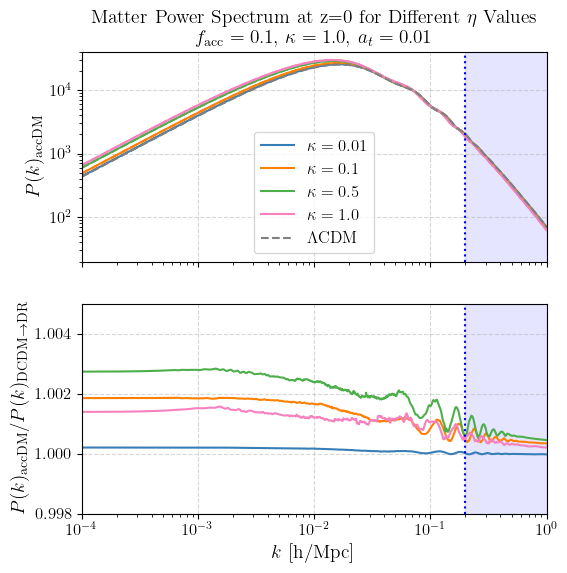

In [17]:
### Plot Pk[eta]/Pk_LCDM for different values of eta
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

colors = colors_colorblind

for kappa in kappa_list:
    color = colors_colorblind[kappa_list.index(kappa)]
    axs[0].plot(kk, np.array(Pk['AccDM', kappa]), label=r'$\kappa = {}$'.format(kappa), color=color)
    axs[0].plot(kk, np.array(Pk_dcdm['DCDM->DR', kappa]), ls='--', color=color)

axs[0].plot(kk, Pk_lcdm, label=r'$\Lambda\mathrm{CDM}$', color='grey', ls='--')   
for kappa in kappa_list:
    color = colors_colorblind[kappa_list.index(kappa)]
    axs[1].plot(kk, np.array(Pk['AccDM', kappa])/np.array(Pk_dcdm['DCDM->DR', kappa]), label=r'$\kappa = {}$'.format(kappa), color=color)

for ax in axs:
    ax.axvline(x=0.2, color='blue', linestyle=':')  
    # ax.text(0.2, 3e4, r'non-linear', color='blue', fontsize=12, verticalalignment='top', rotation=90) 
    ax.set_xscale('log') 
    ax.set_xlim(1e-4, 1)  

axs[0].fill_betweenx([1e-6, 1e6], 0.2, 1, color='blue', alpha=0.1) 
axs[1].fill_betweenx([0.95, 1.2], 0.2, 1, color='blue', alpha=0.1) 

axs[0].set_yscale('log')
axs[0].set_ylim(20, 4e4)
axs[1].set_yscale('linear')
axs[1].set_ylim(0.998, 1.005)
axs[1].set_xlabel(r'$k$ [h/Mpc]')
axs[0].set_ylabel(r'$P(k)_{\mathrm{accDM}}$')
axs[1].set_ylabel(r'$P(k)_{\mathrm{accDM}}/P(k)_{\mathrm{DCDM\to DR}}$')
axs[0].set_title(f'Matter Power Spectrum at z=0 for Different $\eta$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $\kappa = {kappa}$, $a_t = {a_t}$', fontsize=14)
axs[0].legend()
axs[0].grid(ls='--', alpha=0.5)
axs[1].grid(ls='--', alpha=0.5)
plt.show()

Initial conditions for accDM: delta_acc_acc/delta_g_acc = 0.9996608745513403
Initial conditions for DCDM->DR: delta_dr_mon/delta_g_mon = 0.7502775226008094
Initial conditions for accDM: delta_acc_acc/delta_g_acc = 0.9996606096426423
Initial conditions for DCDM->DR: delta_dr_mon/delta_g_mon = 0.7443465208666756
Initial conditions for accDM: delta_acc_acc/delta_g_acc = 0.9996606462801879
Initial conditions for DCDM->DR: delta_dr_mon/delta_g_mon = 0.6487730069027853


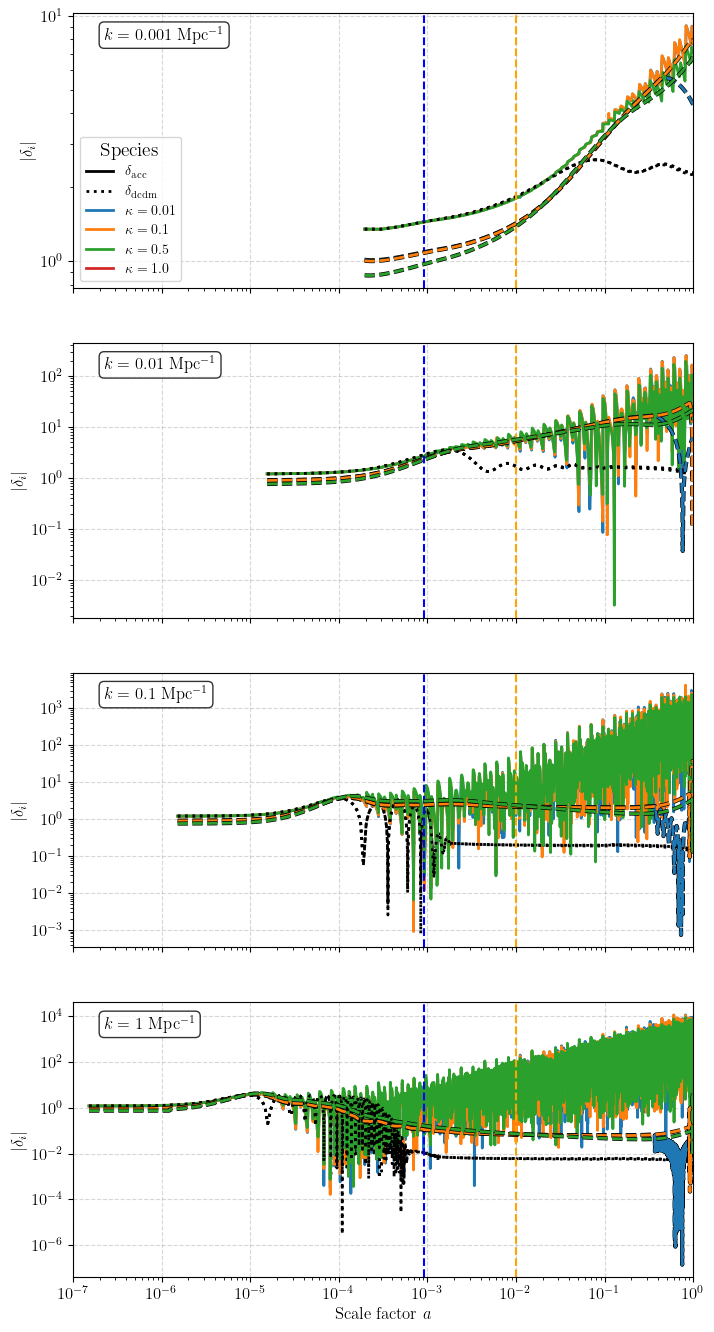

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import copy

# Dynamically set subplots based on the number of k_values
# Added dpi=300 for publication-ready high resolution
fig, axs = plt.subplots(len(k_values), 1, figsize=(8, 4 * len(k_values)), sharex=True, dpi=100)

# Ensure axs is iterable even if there's only 1 k_value
if len(k_values) == 1:
    axs = [axs]

# Set up a colormap to continuously map eta values
# cmap = cm.viridis
# norm = mcolors.Normalize(vmin=min(eta_list), vmax=max(eta_list))

colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']  # Cycle through default matplotlib colors

for idx, k in enumerate(k_values):
    for kappa in kappa_list[:-1]:
        # Get the specific color for this eta value from the colormap
        color = colors[kappa_list.index(kappa) % len(colors)]  # Safe indexing in case kappa_list > colors
        
        a_acc = a['AccDM', kappa, k]
        a_mon = a['DCDM->DR', kappa, k]
        delta_cdm_acc = np.abs(delta_cdm['AccDM', kappa, k])
        delta_dcdm_acc = np.abs(delta_dcdm['AccDM', kappa, k])
        delta_g_acc = np.abs(delta_g['AccDM', kappa, k]) 
        delta_g_mon = np.abs(delta_g['DCDM->DR', kappa, k])       
        delta_acc_acc = np.abs(delta_acc['AccDM', kappa, k])
        delta_dcdm_mon = np.abs(delta_dcdm['DCDM->DR', kappa, k])
        delta_dr_mon = np.abs(delta_dr['DCDM->DR', kappa, k])
            
        if k == k_values[0]:  # Only print for the first k value to avoid clutter
            print(f'Initial conditions for accDM: delta_acc_acc/delta_g_acc = {delta_acc_acc[0]/delta_g_acc[0]}')        
            print(f'Initial conditions for DCDM->DR: delta_dr_mon/delta_g_mon = {delta_dr_mon[0]/delta_g_mon[0]}')

        delta_ur_acc = np.abs(delta_ur['AccDM', kappa, k])
        
        # for i in range(len(delta_dr_mon)):
        #     if delta_dr_mon[i] == 0 or np.isnan(delta_dr_mon[i]) or np.isinf(delta_dr_mon[i]):
        #         print(kappa, i)
        #         delta_dr_mon[i] = 1e-5  # Set to a very small number to avoid log(0) issues
                
        axs[idx].plot(a_acc, delta_acc_acc, 
                      label=rf'$\delta_{{\mathrm{{acc}}}}$' if (idx == 0 and kappa == kappa_list[0]) else None, 
                      color=color, linewidth=2, ls='-')
        axs[idx].plot(a_mon, delta_dr_mon, 
                      color=color, linewidth=2, ls='--', path_effects=[pe.withStroke(linewidth=3, foreground='black')], zorder=10)
        
    
    # axs[idx].plot(a_acc, delta_dcdm_acc, 
    #                   label=rf'$\delta_{{\mathrm{{dcdm}}}}$' if (idx == 0 and kappa == kappa_list[0]) else None, 
    #                   color='black', linewidth=2, ls='--')
        axs[idx].plot(a_acc, delta_g_acc, 
                        label=rf'$\delta_{{\mathrm{{dcdm}}}}$' if (idx == 0 and kappa == kappa_list[0]) else None, 
                        color='black', linewidth=2, ls=':')
        
    # Scale and grid configurations per subplot
    axs[idx].set_xscale('log')
    axs[idx].set_xlim(1e-7, 1)
    axs[idx].set_yscale('log')
    # axs[idx].set_ylim(1e-6, 20)
    axs[idx].grid(ls='--', alpha=0.5)
    axs[idx].set_ylabel(r'$|\delta_i|$', fontsize=12)
    
    # axs[idx].axvline(x=1/(1+z_eq[kappa]['z_eq']), color='grey', linestyle='--') # Matter-radiation equality
    axs[idx].axvline(x=a_t, color='orange', linestyle='--') # Acceleration
    axs[idx].axvline(x=1/(1+1100), color='blue', linestyle='--') # Recombination
    
    # Add a clean text box to denote the 'k' value for each subplot
    axs[idx].text(0.05, 0.95, f'$k = {k}$ Mpc$^{{-1}}$', transform=axs[idx].transAxes, 
                  fontsize=12, verticalalignment='top', 
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# X-label is only needed on the bottom axis due to sharex=True
axs[-1].set_xlabel(r'Scale factor $a$', fontsize=12)

# Create a master title for the whole figure
# fig.suptitle(f'Perturbation Evolution for Different $\eta$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$, $\eta={eta}$', 
#              fontsize=14, y=0.98)

# --- Legend and Colorbar Configuration ---

# 1. Legend for the species (line styles)
handles, labels = axs[0].get_legend_handles_labels()
# Force the legend lines to be neutral (black) so they aren't tied to a specific eta color
neutral_handles = []
for h in handles:
    new_h = copy.copy(h)
    new_h.set_color('black')
    neutral_handles.append(new_h)
    
### Add eta colors to the legend
color_handles = [Line2D([0], [0], color=colors[i % len(colors)], lw=2, label=rf'$\eta={eta}$') for i, eta in enumerate(kappa_list)]

all_handles = neutral_handles + color_handles
all_labels = labels + [rf'$\kappa={kappa}$' for kappa in kappa_list]

axs[0].legend(all_handles, all_labels, fontsize=10, loc='lower left', frameon=True, title="Species")

# Adjust layout to prevent clipping of the suptitle
plt.subplots_adjust(top=0.9)
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\k'
<>:19: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_201756/3665975363.py:19: SyntaxWarning: invalid escape sequence '\k'
  ax.set_title(f'CMB TT Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)


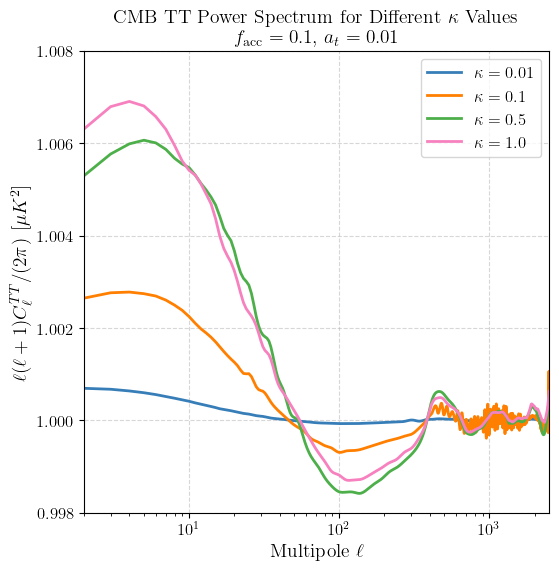

In [22]:
### Plot TT spectrum
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for kappa in kappa_list:
    ll_acc = ll['AccDM', kappa]
    clTT_acc = ll_acc*(1+ll_acc)*clTT['AccDM', kappa]/(2*np.pi)
    ll_mon = ll['DCDM->DR', kappa]
    clTT_mon = clTT['DCDM->DR', kappa]/(2*np.pi)*ll_mon*(1+ll_mon)
    
    ax.plot(ll_acc, clTT_acc/clTT_mon, label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '-', color=colors_colorblind[kappa_list.index(kappa)])
    
ax.set_xscale('log')
ax.set_xlim(2, 2500)
ax.set_yscale('linear')
ax.set_ylim(0.998, 1.008)
# ax.set_ylim(1e-3, 1e4)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/(2\pi)$ [$\mu K^2$]')
ax.set_title(f'CMB TT Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)
ax.legend()
ax.grid(ls='--', alpha=0.5)
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\k'
<>:19: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_201756/3063699648.py:19: SyntaxWarning: invalid escape sequence '\k'
  ax.set_title(f'CMB TE Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)


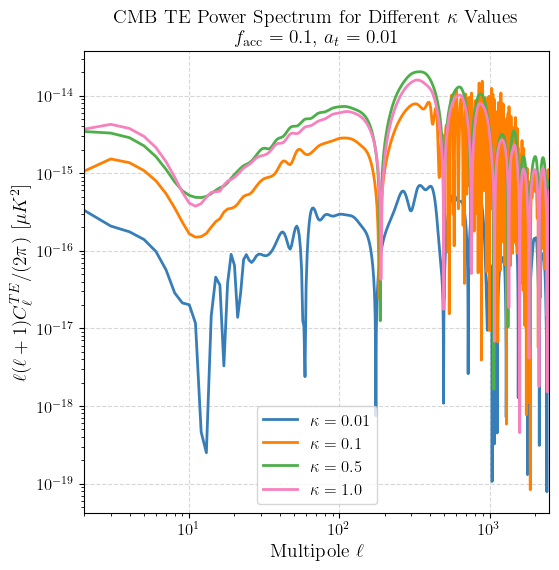

In [23]:
### Plot TE spectrum
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for kappa in kappa_list:
    ll_acc = ll['AccDM', kappa]
    clTE_acc = ll_acc*(1+ll_acc)*clTE['AccDM', kappa]/(2*np.pi)
    ll_mon = ll['DCDM->DR', kappa]
    clTE_mon = clTE['DCDM->DR', kappa]/(2*np.pi)*ll_mon*(1+ll_mon)
    
    ax.plot(ll_acc, np.abs(clTE_acc-clTE_mon), label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '-', color=colors_colorblind[kappa_list.index(kappa)])
    
ax.set_xscale('log')
ax.set_xlim(2, 2500)
ax.set_yscale('log')
# ax.set_ylim(0.8, 1.5)
# ax.set_ylim(1e-3, 1e4)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell^{TE}/(2\pi)$ [$\mu K^2$]')
ax.set_title(f'CMB TE Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)
ax.legend()
ax.grid(ls='--', alpha=0.5)
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\k'
<>:19: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_201756/3231665288.py:19: SyntaxWarning: invalid escape sequence '\k'
  ax.set_title(f'CMB EE Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)


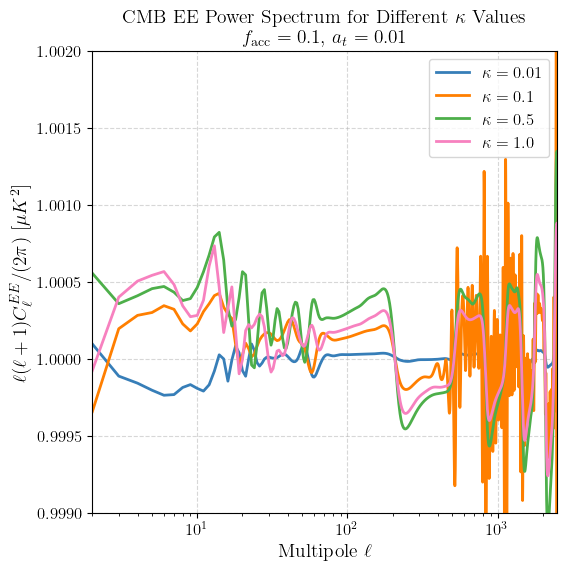

In [26]:
### Plot TT spectrum
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for kappa in kappa_list:
    ll_acc = ll['AccDM', kappa]
    clEE_acc = ll_acc*(1+ll_acc)*clEE['AccDM', kappa]/(2*np.pi)
    ll_mon = ll['DCDM->DR', kappa]
    clEE_mon = clEE['DCDM->DR', kappa]/(2*np.pi)*ll_mon*(1+ll_mon)
    
    ax.plot(ll_acc, clEE_acc/clEE_mon, label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '-', color=colors_colorblind[kappa_list.index(kappa)])
    
ax.set_xscale('log')
ax.set_xlim(2, 2500)
ax.set_yscale('linear')
ax.set_ylim(0.999, 1.002)
# ax.set_ylim(1e-3, 1e4)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell^{EE}/(2\pi)$ [$\mu K^2$]')
ax.set_title(f'CMB EE Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)
ax.legend()
ax.grid(ls='--', alpha=0.5)
plt.show()